# Toy Experiment demonstrating how to use the CCA-Zoo package to compute CCA metrics

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from cca_zoo.linear import CCA
from cca_zoo.datasets import JointData

In [2]:
def plot_CCA_all_latents(dims, scores):
    plt.figure(figsize=(13,4))
    plt.plot(dims, scores, "o", label="CCA")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA value")
    plt.xticks(dims)
    plt.ylim(0,1)
    plt.show()
    
def plot_features(z1, z2, latent):
    latent_label = latent+1
    # Plot the view in the shared latent space for the desired latent 
    plt.figure(figsize=(6,3))
    plt.title('Correlation in shared latent space for latent '+str(latent_label))
    plt.scatter(z1[:,latent], z2[:,latent], marker='.')
    plt.xlabel('Feature '+str(latent_label)+' for model 1')
    plt.ylabel('Feature '+str(latent_label)+' for model 2')
    plt.show()

## 1. Generate correlated data from a linear latent variable model 

In [3]:
ndims = 50
data = JointData(
    n_views=2,
    n_samples=300,
    n_features=[50, 50],
    latent_dimensions=ndims,
    signal_to_noise=2.0,
    random_state=0,
)
train_views = data.sample() # shape (n_views, n_samples, ndims)
test_views  = data.sample() # shape (n_views, n_samples, ndims)

dims = np.arange(1,ndims+1)

# Fit the CCA
model = CCA(latent_dimensions=ndims).fit(train_views) 

# Canonical correlations on the test data, one value per latent dimension 
corrs = model.score(test_views) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))

CCA canonical correlations: [0.99163671 0.99189366 0.98947048 0.99169984 0.9873977  0.98358069
 0.98664817 0.9866303  0.98604826 0.98402437 0.98625777 0.98507634
 0.98226205 0.9811451  0.97365301 0.98390153 0.98231007 0.97765747
 0.97711106 0.97369371 0.9669787  0.96983298 0.96531348 0.96443581
 0.96362879 0.95658131 0.96303477 0.96706149 0.93494011 0.93698
 0.94203057 0.93707175 0.92828935 0.90294297 0.90412001 0.8980841
 0.88903631 0.91472335 0.81552269 0.81117523 0.84171559 0.79571205
 0.72553271 0.58929297 0.58235053 0.34588049 0.22368477 0.13058592
 0.18433501 0.18427316]


### Plot the CCA value for each latent

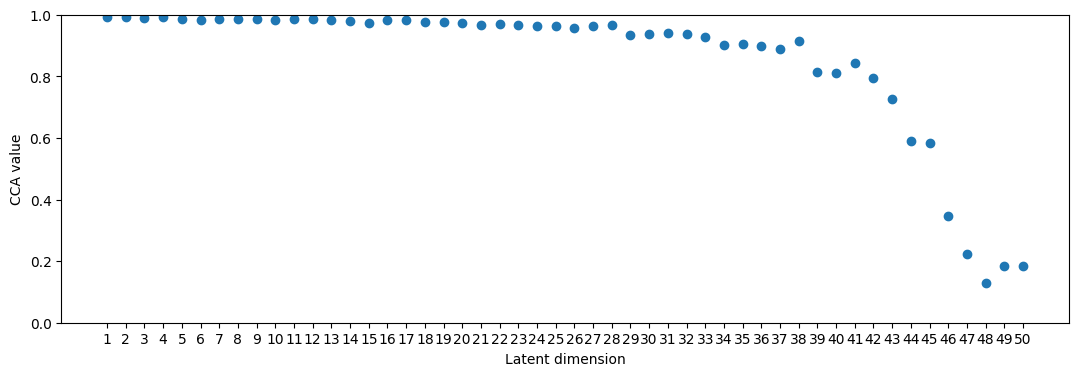

In [4]:
plot_CCA_all_latents(dims, corrs)

### Visualize correlations between latents in shared latent space

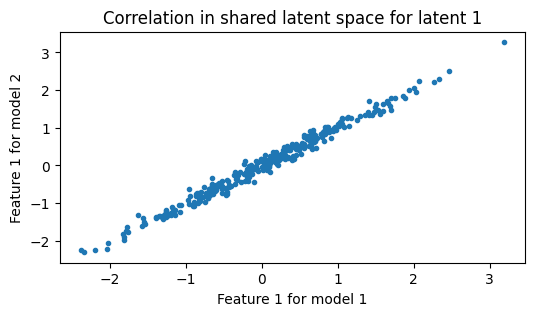

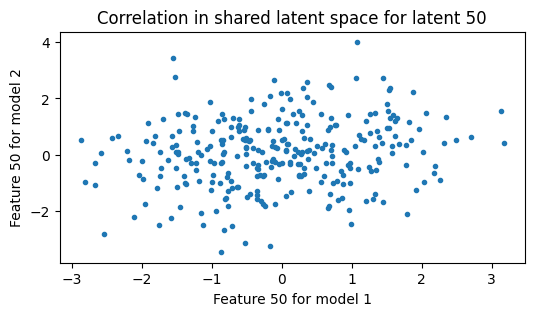

In [5]:
# Project views into the shared latent space
z1, z2 = model.transform(test_views) 

plot_features(z1, z2, 0)
plot_features(z1, z2, 49)

## 2. Toy experiment: generate a set of random vectors and apply a linear transformation

### 2.1 Exact linear transformation, no noise. CCA values should all be 1!

In [6]:
ndims = 50
nsamples = 300
model1_samples = np.random.normal(size=(nsamples, ndims))
A = np.random.normal(size=(ndims, ndims))
model2_samples = model1_samples @ A

# concatenate them along the first dimension such that we have shape (n_views, nsamples, ndims)
toy_train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(toy_train_views.shape)
dims = np.arange(1,ndims+1)

# Fit the CCA
toy_model = CCA(latent_dimensions=ndims).fit(toy_train_views) 

# Canonical correlations on the test data, one value per latent dimension 
model1_test_samples = np.random.normal(size=(nsamples, ndims))
model2_test_samples = model1_test_samples @ A
toy_test_views = np.concatenate((np.expand_dims(model1_test_samples, 0), np.expand_dims(model2_test_samples, 0)), axis=0)

toy_corrs = toy_model.score(toy_test_views) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(toy_corrs, ndims))


(2, 300, 50)
CCA canonical correlations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


#### Plot the CCA value for each latent

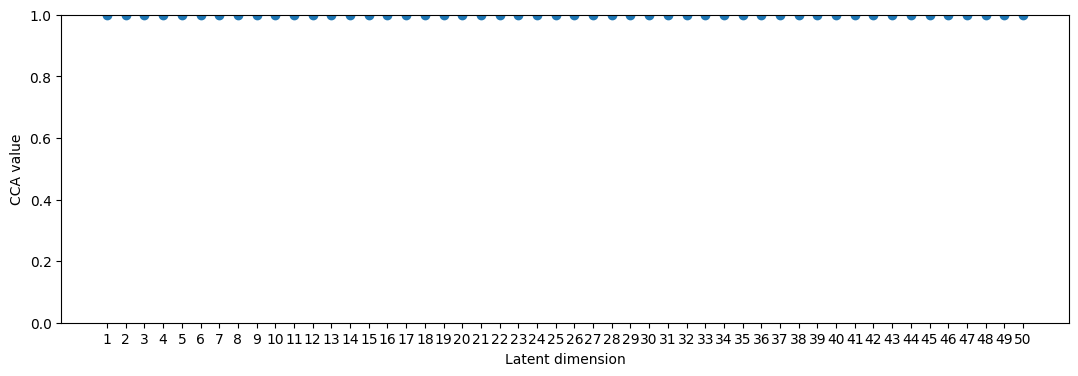

In [7]:
plot_CCA_all_latents(dims, toy_corrs)

#### Visualize the latents in the shared latent space

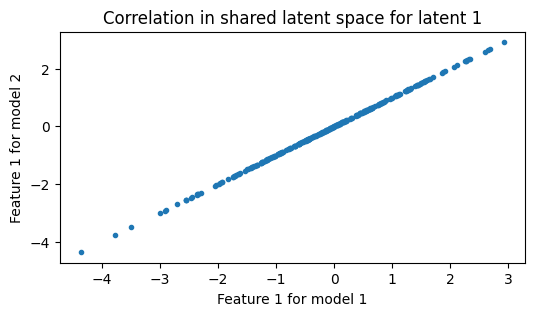

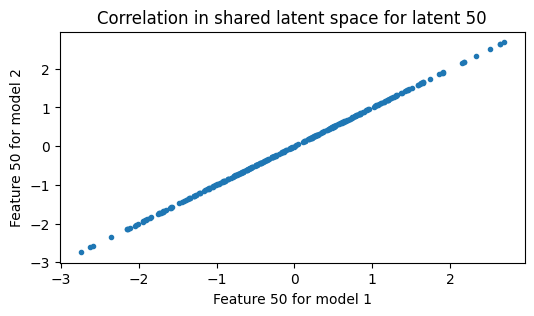

In [8]:
z1, z2 = toy_model.transform(toy_test_views) 

plot_features(z1, z2, 0)
plot_features(z1, z2, 49)

### 2.2 Now let's add some noise to the transformation

In [9]:
ndims = 50
nsamples = 300
model1_samples = np.random.normal(size=(nsamples, ndims))
A = np.random.normal(size=(ndims, ndims))
model2_samples = model1_samples @ A + np.random.randn(nsamples, ndims)

# concatenate them along the first dimension such that we have shape (n_views, nsamples, ndims)
toy_train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(toy_train_views.shape)
dims = np.arange(1,ndims+1)

# Fit the CCA
toy_model = CCA(latent_dimensions=ndims).fit(toy_train_views) 

# Canonical correlations on the test data, one value per latent dimension 
model1_test_samples = np.random.normal(size=(nsamples, ndims))
model2_test_samples = model1_test_samples @ A + 0.1 * np.random.randn(nsamples, ndims)
toy_test_views = np.concatenate((np.expand_dims(model1_test_samples, 0), np.expand_dims(model2_test_samples, 0)), axis=0)

toy_corrs = toy_model.score(toy_test_views) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(toy_corrs, ndims))

(2, 300, 50)
CCA canonical correlations: [0.99935532 0.99901356 0.99928251 0.99885763 0.99889722 0.99922692
 0.99917551 0.99886988 0.99887264 0.99858836 0.99901817 0.99864008
 0.99763145 0.99853459 0.99804568 0.99839339 0.99716075 0.9983397
 0.99784662 0.99744348 0.99802456 0.99715571 0.99793982 0.9972797
 0.99796634 0.99545025 0.99519686 0.99640078 0.99736943 0.99616409
 0.99405468 0.9948232  0.99268047 0.99306746 0.9882443  0.98836847
 0.98924182 0.99048291 0.97979471 0.96789579 0.97792898 0.97295537
 0.96326097 0.94796308 0.93634574 0.83611928 0.76263514 0.51882464
 0.4979604  0.27744943]


#### Plot the CCA value for each latent

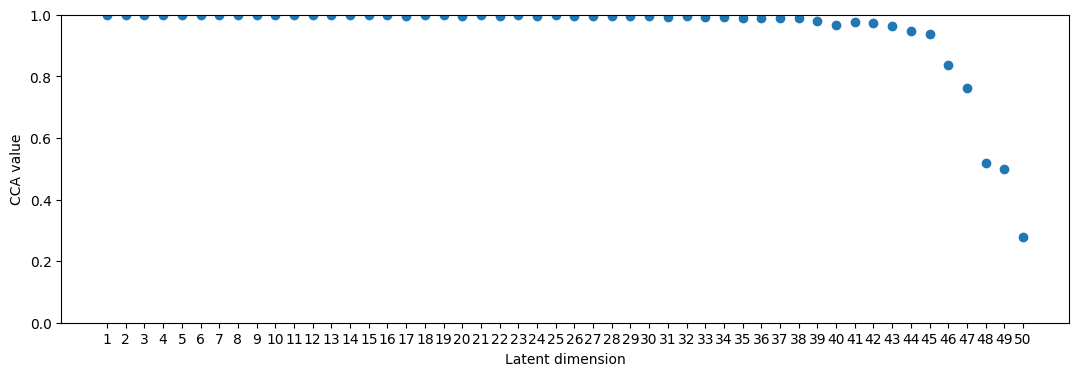

In [10]:
plot_CCA_all_latents(dims, toy_corrs)

#### Visualize the latents in the shared latent space

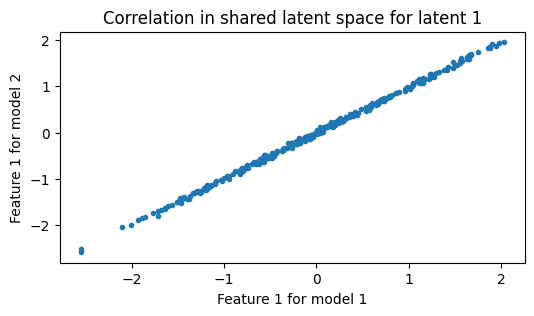

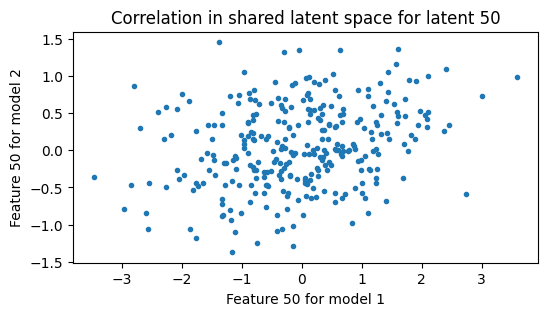

In [11]:
z1, z2 = toy_model.transform(toy_test_views) 

plot_features(z1, z2, 0)
plot_features(z1, z2, 49)

### 2.3 Now let's attempt a nonlinear transformation

In [12]:
ndims = 50
nsamples = 300
model1_samples = np.random.normal(size=(nsamples, ndims))
A = np.random.normal(size=(ndims, ndims))
model2_samples = np.tanh(model1_samples @ A)

# concatenate them along the first dimension such that we have shape (n_views, nsamples, ndims)
toy_train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(toy_train_views.shape)
dims = np.arange(1,ndims+1)

# Fit the CCA
toy_model = CCA(latent_dimensions=ndims).fit(toy_train_views) 

# Canonical correlations on the test data, one value per latent dimension 
model1_test_samples = np.random.normal(size=(nsamples, ndims))
model2_test_samples = np.tanh(model1_test_samples @ A)
toy_test_views = np.concatenate((np.expand_dims(model1_test_samples, 0), np.expand_dims(model2_test_samples, 0)), axis=0)

toy_corrs = toy_model.score(toy_test_views) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(toy_corrs, ndims))

(2, 300, 50)
CCA canonical correlations: [9.14728607e-01 8.88292361e-01 8.85841384e-01 8.72068567e-01
 9.05057937e-01 9.09820898e-01 9.08719864e-01 8.63487624e-01
 8.55157740e-01 8.45628487e-01 8.59474944e-01 8.36997086e-01
 8.12120332e-01 8.66438446e-01 7.97208509e-01 8.33768145e-01
 8.35821156e-01 8.03390776e-01 7.89730291e-01 7.13152613e-01
 8.26690611e-01 7.63361089e-01 7.73650564e-01 7.87474124e-01
 7.67442735e-01 7.61232279e-01 6.71188983e-01 7.19917453e-01
 5.80405005e-01 7.21724016e-01 6.67126080e-01 5.76251384e-01
 6.66134275e-01 6.15791188e-01 6.67632891e-01 5.77259065e-01
 3.12620820e-01 4.42131130e-01 4.27088460e-01 3.64173580e-01
 2.14198930e-01 2.87900796e-01 3.34789241e-01 2.36147867e-01
 1.85903513e-01 2.39898297e-01 2.25056771e-01 1.34395412e-01
 2.00093452e-01 7.39195545e-04]


#### Plot the CCA values for each latent

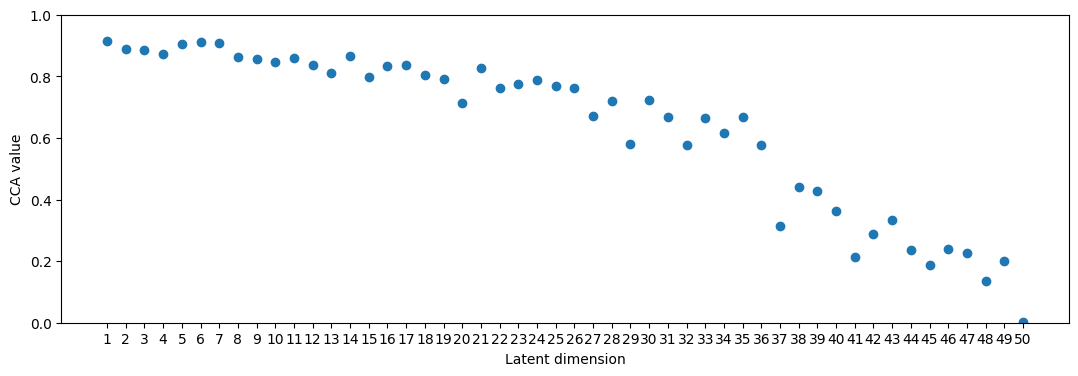

In [13]:
plot_CCA_all_latents(dims, toy_corrs)

#### Visualize the latents in the shared latent space

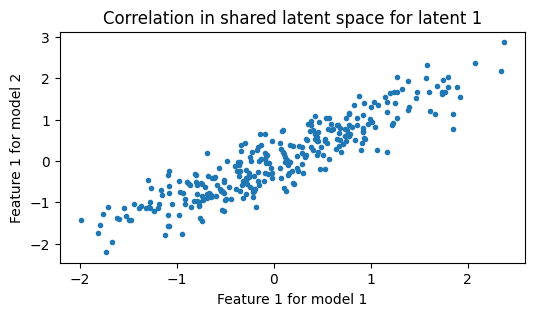

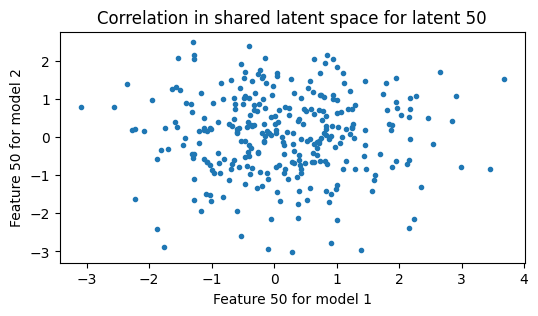

In [14]:
z1, z2 = toy_model.transform(toy_test_views) 

plot_features(z1, z2, 0)
plot_features(z1, z2, 49)